## Ideal Fertilizer Range (Nitrogen Usage Analysis)

Ideal Fertilizer Range: 5217315.88 to 15438817.7 kg


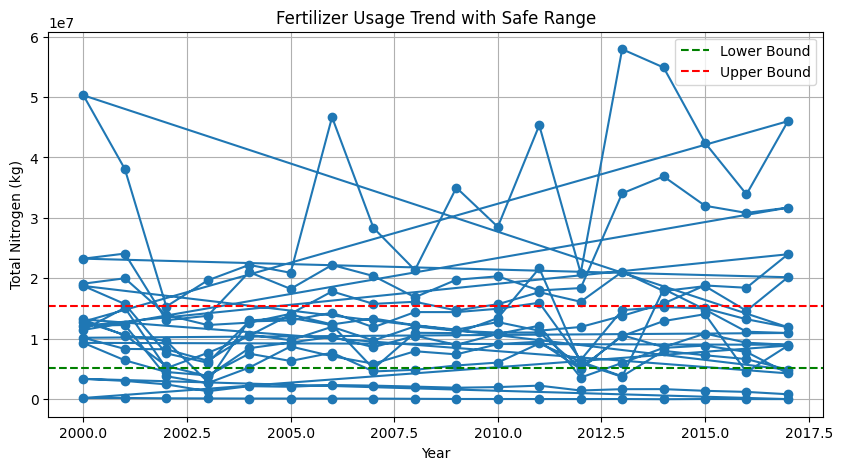

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/tamilnadu_rice_2000_2017.csv')

fert = df[['Year', 'Total_N_kg']].dropna()

low = fert['Total_N_kg'].quantile(0.25)
high = fert['Total_N_kg'].quantile(0.75)

print(f"Ideal Fertilizer Range: {round(low,2)} to {round(high,2)} kg")

plt.figure(figsize=(10,5))
plt.plot(fert['Year'], fert['Total_N_kg'], marker='o')
plt.axhline(low, color='green', linestyle='--', label='Lower Bound')
plt.axhline(high, color='red', linestyle='--', label='Upper Bound')

plt.title("Fertilizer Usage Trend with Safe Range")
plt.xlabel("Year")
plt.ylabel("Total Nitrogen (kg)")
plt.legend()
plt.grid()
plt.show()

## Groundwater Sustainability Analysis

Optimal Rainfall Range: 2.94 to 3.28


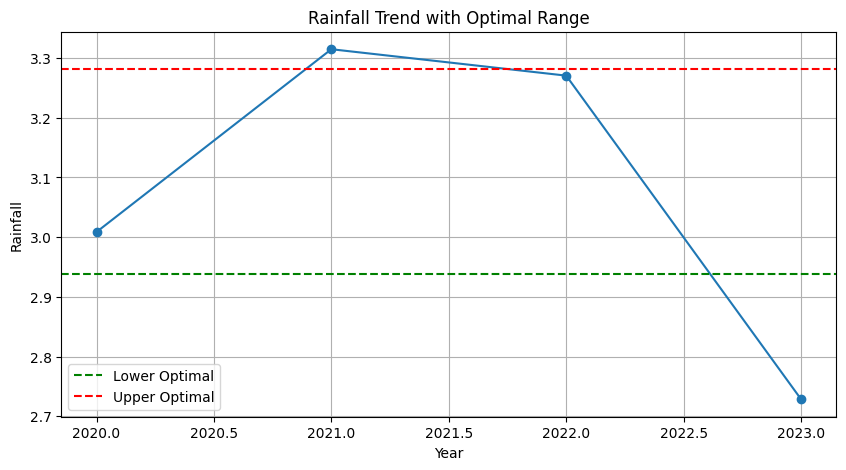

In [2]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('../data/NDTV/climate_data/chirps_rainfall_timeseries.xlsx')

df['date'] = pd.to_datetime(df['date'])
df['Year'] = df['date'].dt.year

rain = df.groupby('Year')['precipitation'].mean().reset_index()

low_rain = rain['precipitation'].quantile(0.25)
high_rain = rain['precipitation'].quantile(0.75)

print(f"Optimal Rainfall Range: {round(low_rain,2)} to {round(high_rain,2)}")

plt.figure(figsize=(10,5))
plt.plot(rain['Year'], rain['precipitation'], marker='o')

plt.axhline(low_rain, color='green', linestyle='--', label='Lower Optimal')
plt.axhline(high_rain, color='red', linestyle='--', label='Upper Optimal')

plt.title("Rainfall Trend with Optimal Range")
plt.xlabel("Year")
plt.ylabel("Rainfall")
plt.legend()
plt.grid()
plt.show()

## Smart Agricultural Recommendation System

In [ ]:
import pandas as pd


df = pd.read_csv('../data/tamilnadu_rice_2000_2017.csv')

fert = df[['Total_N_kg']].dropna()
low = fert['Total_N_kg'].quantile(0.25)
high = fert['Total_N_kg'].quantile(0.75)

rain = df[['Rainfall_mm']].dropna()
low_rain = rain['Rainfall_mm'].quantile(0.25)
high_rain = rain['Rainfall_mm'].quantile(0.75)

critical_level = -5  
safe_level = -2      

def recommendation(fertilizer, rainfall, groundwater):

    if fertilizer > high:
        return "Reduce fertilizer usage (Overuse detected)"

    elif rainfall < low_rain:
        return "Increase irrigation (Low rainfall)"

    elif groundwater < critical_level:
        return "Avoid groundwater overuse (Critical depletion)"

    else:
        return "Optimal conditions for harvesting"


print("Recommendation:", recommendation(50000, 800, -5))

print("\n--- SYSTEM THRESHOLDS ---")
print(f"Fertilizer Range: {round(low,2)} to {round(high,2)}")
print(f"Rainfall Range: {round(low_rain,2)} to {round(high_rain,2)}")
print(f"Groundwater Safe Level: {safe_level}")
print(f"Groundwater Critical Level: {critical_level}")

Recommendation: 💧 Increase irrigation (Low rainfall)

--- SYSTEM THRESHOLDS ---
Fertilizer Range: 5217315.88 to 15438817.7
Rainfall Range: 1200.0 to 1200.0
Groundwater Safe Level: -2
Groundwater Critical Level: -5


## Comparative Analysis: Tamil Nadu vs Karnataka

Columns: Index(['Dist Code', 'Year', 'State Code', 'State Name', 'Dist Name', 'Crop',
       'Area_ha', 'Yield_kg_per_ha', 'N_req_kg_per_ha', 'P_req_kg_per_ha',
       'K_req_kg_per_ha', 'Total_N_kg', 'Total_P_kg', 'Total_K_kg',
       'Temperature_C', 'Humidity_%', 'pH', 'Rainfall_mm', 'Wind_Speed_m_s',
       'Solar_Radiation_MJ_m2_day'],
      dtype='str')
Sample crops: <StringArray>
['rice', 'maize', 'chickpea', 'cotton']
Length: 4, dtype: str
Rows after filtering: 1612
Rows after cleaning: 1612

Summary:
             Yield_kg_per_ha  Rainfall_mm    Total_N_kg
State Name                                            
Karnataka       2151.539757       1200.0  3.717651e+06
Tamil Nadu      2813.897420       1200.0  1.166673e+07


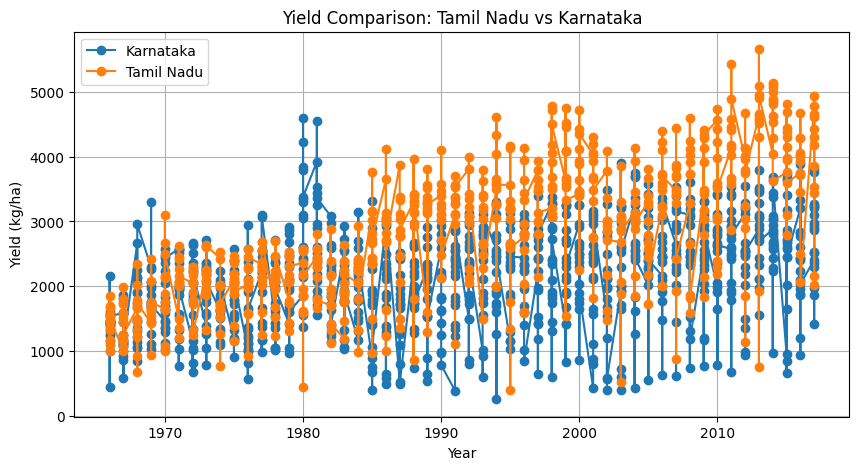

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('../data/archive/Custom_Crops_yield_Historical_Dataset.csv')

df.columns = df.columns.str.strip()

print("Columns:", df.columns)

df['Crop'] = df['Crop'].astype(str).str.strip().str.lower()

print("Sample crops:", df['Crop'].unique()[:10])

df = df[
    (df['Crop'].str.contains('rice') | df['Crop'].str.contains('paddy')) &
    (df['State Name'].isin(['Tamil Nadu','Karnataka']))
]

print("Rows after filtering:", len(df))

df = df[['State Name','Year','Yield_kg_per_ha','Rainfall_mm','Total_N_kg']]

df = df.dropna(subset=['Yield_kg_per_ha'])

print("Rows after cleaning:", len(df))

if df.empty:
    print("❌ No matching data found. Likely dataset doesn't include Rice for both states.")
else:
    summary = df.groupby('State Name')[['Yield_kg_per_ha','Rainfall_mm','Total_N_kg']].mean()
    print("\nSummary:\n", summary)

    plt.figure(figsize=(10,5))

    for state in df['State Name'].unique():
        temp = df[df['State Name'] == state].sort_values('Year')
        plt.plot(temp['Year'], temp['Yield_kg_per_ha'], marker='o', label=state)

    plt.title("Yield Comparison: Tamil Nadu vs Karnataka")
    plt.xlabel("Year")
    plt.ylabel("Yield (kg/ha)")
    plt.legend()
    plt.grid()

    plt.show()